In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
use_english_fallback = True

# 加載原始圖像 (假設圖像在與程式相同的目錄)
# 注意：請根據實際情況修改圖像路徑
image_path = "./test.png"  # 你需要將此改為實際圖像路徑
original_image = cv2.imread(image_path)

# 檢查圖像是否成功加載
if original_image is None:
    print("Error: Cannot load the image. Please check the path.")
    exit()

# 轉換為灰度圖像
gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

# 調整大小為目標圖像的尺寸（根據右側圖像約 70x90 像素）
target_height = 90
target_width = 70
small_image = cv2.resize(
    gray_image, (target_width, target_height), interpolation=cv2.INTER_AREA
)

In [3]:
def random_dither(image):
    height, width = image.shape
    result = np.zeros((height, width), dtype=np.uint8)

    # 使用隨機閾值進行二值化
    for y in range(height):
        for x in range(width):
            # 根據像素亮度決定隨機閾值範圍
            if image[y, x] > np.random.randint(100, 150):
                result[y, x] = 255

    return result

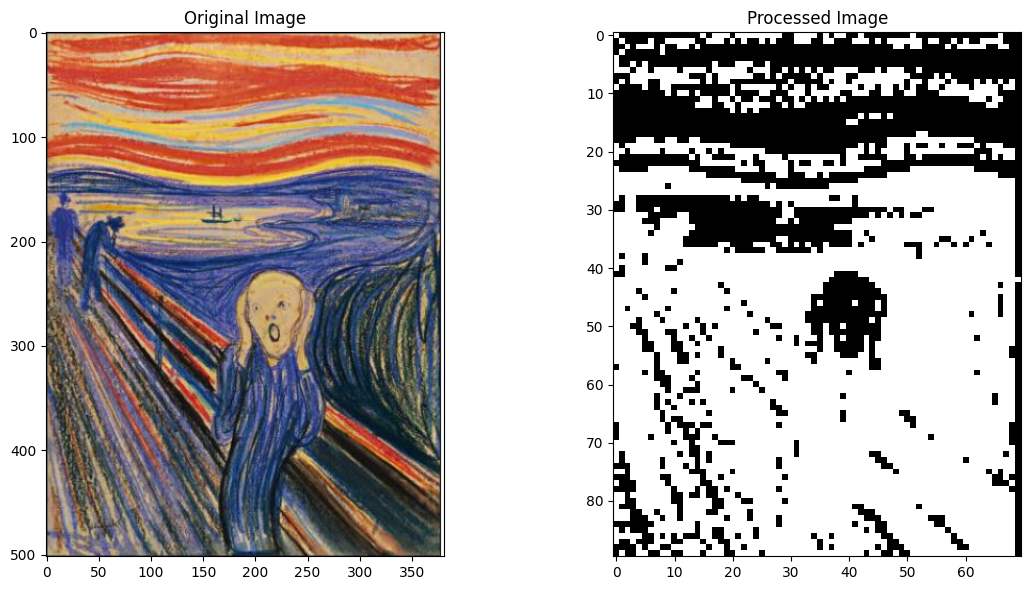

In [4]:
# 應用隨機抖動
binary_image = random_dither(small_image)

# 顯示結果
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
# 轉換回RGB以正確顯示
rgb_original = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_original)
if use_english_fallback:
    plt.title("Original Image")
else:
    plt.title("原圖")
plt.axis("on")

plt.subplot(1, 2, 2)
plt.imshow(binary_image, cmap="binary")
if use_english_fallback:
    plt.title("Processed Image")
else:
    plt.title("經過處理後的圖")
plt.axis("on")

plt.tight_layout()
plt.savefig(
    "./comparison_result.png",
    dpi=300,
    bbox_inches="tight",
)  # 增加DPI以獲得更清晰的圖像

# 保存處理後的圖像（確保使用絕對路徑）
# cv2.imwrite("./processed_scream_.png", binary_image)
plt.show("Processed Image", binary_image)